In [41]:
import numpy as np
import matplotlib.pyplot as plt
from few.utils.utility import get_fundamental_frequencies, get_separatrix
from scipy.optimize import differential_evolution, brentq

## In generic, let's try and find a point where multiple resonance conditions are satisfied.

i.e., for two sets of integers $(m_1, k_1, n_1)$ and $(m_2, k_2, n_2)$, we want to identify (if it exists) the point $(a, p, e, x_I)$ where

$$ m_1 \Omega_\phi + k_1 \Omega_\theta + n_1 \Omega_r = m_2 \Omega_\phi + k_2 \Omega_\theta + n_2 \Omega_r = 0$$



In [164]:
# pick two low-order resonance conditions

m1 = -2
k1 = 4
n1 = -3

m2 = -2
k2 = 5
n2 = -5

def res_cond(p, a, e, x, m, k, n):
    frs = get_fundamental_frequencies(a, p, e, x)
    return (frs[0]*m + frs[1]*k + frs[2]*n)


In [165]:
ev = np.linspace(0., 0.99, 101)
xv = np.linspace(0.11, 0.99, 101)

p_res_1 = np.zeros((ev.size, xv.size))
p_res_2 = np.zeros((ev.size, xv.size))

a = 0.9

for k in range(len(ev)):
    for j in range(len(xv)):
        try:
            p_res_1[k, j] = brentq(res_cond, get_separatrix(a, ev[k], xv[j])+1e-8, 200., args=(a, ev[k], xv[j], m1, k1, n1), xtol=1e-15)
        except ValueError:
            p_res_1[k, j] = np.nan
        try:
            p_res_2[k, j] = brentq(res_cond, get_separatrix(a, ev[k], xv[j])+1e-8, 200., args=(a, ev[k], xv[j], m2, k2, n2), xtol=1e-15)
        except ValueError:
            p_res_2[k, j] = np.nan

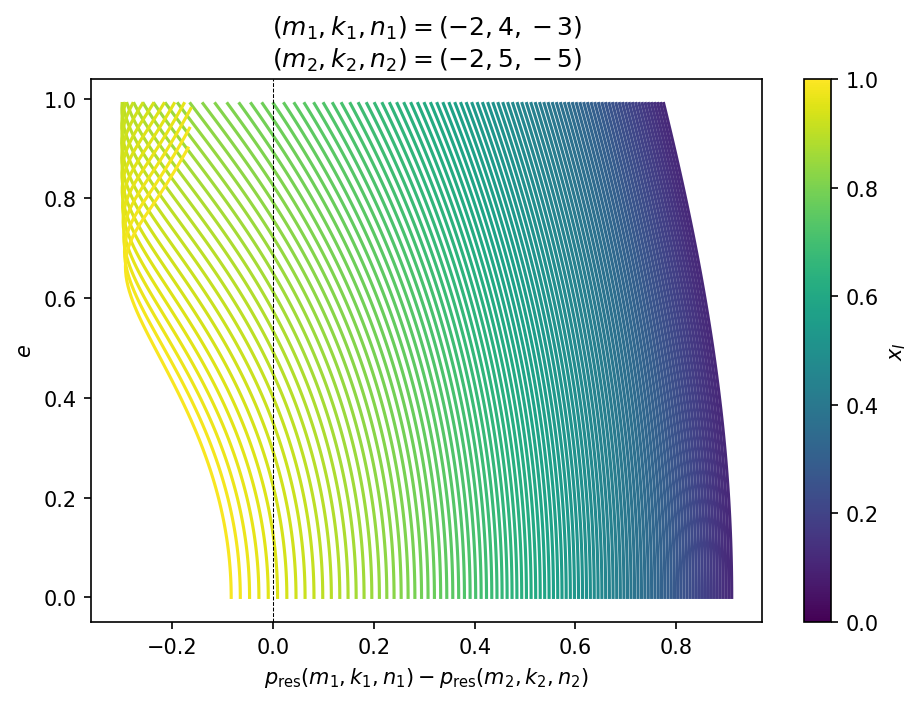

In [166]:
to_plot = p_res_1 - p_res_2
cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(dpi=150)
for k in range(len(xv)):
    ax.plot(to_plot[:,k], ev, c=cmap(xv[k]))
# plt.colorbar()
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax, label=r"$x_I$")
plt.axvline(0, color='black', linestyle='--', lw=0.5)
plt.xlabel(r"$p_\mathrm{res}(m_1, k_1, n_1) - p_\mathrm{res}(m_2, k_2, n_2)$")
plt.ylabel(r"$e$")
plt.title(fr"$(m_1, k_1, n_1) = ({m1:d}, {k1:d}, {n1:d})$" + "\n" + fr"$(m_2, k_2, n_2) = ({m2:d}, {k2:d}, {n2:d})$")
plt.tight_layout()
plt.show()


The above result implies the existence of a third resonance for indices $(m_1 - m_2, k_1 - k_2, n_1 - n_2)$ at the crossing point. We verify this by performing the same analysis as above with these new mode indices and showing that this surface also intersects with the others at this point.

In [172]:
# pick two low-order resonance conditions

m3 = m1 - m2
k3 = k1 - k2
n3 = n1 - n2

p_res_3 = np.zeros((ev.size, xv.size))

for k in range(len(ev)):
    for j in range(len(xv)):
        try:
            p_res_3[k, j] = brentq(res_cond, get_separatrix(a, ev[k], xv[j])+1e-8, 200., args=(a, ev[k], xv[j], m3, k3, n3), xtol=1e-15)
        except ValueError:
            p_res_3[k, j] = np.nan


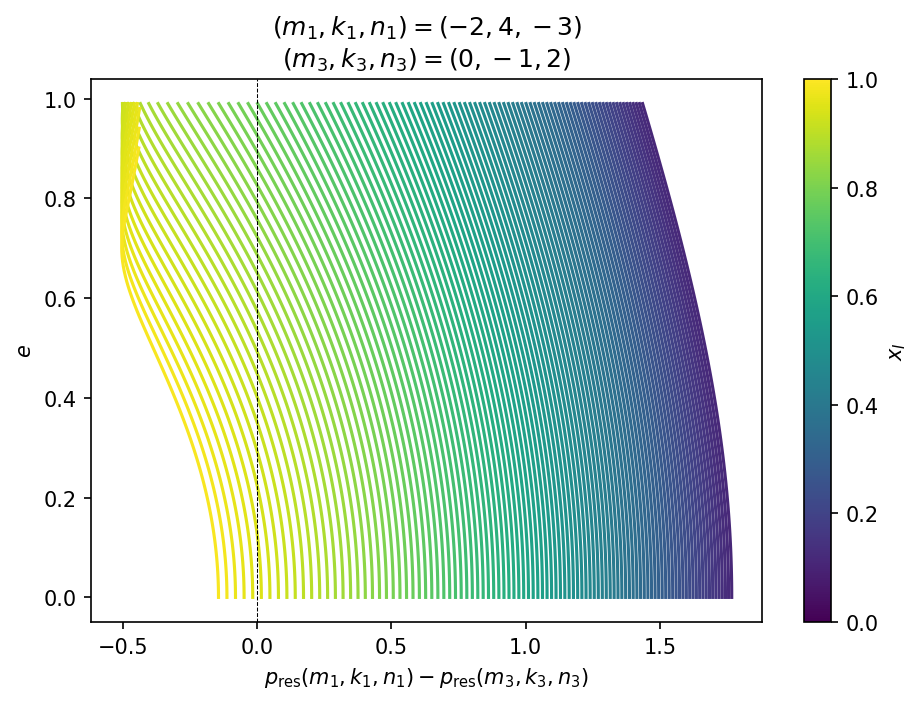

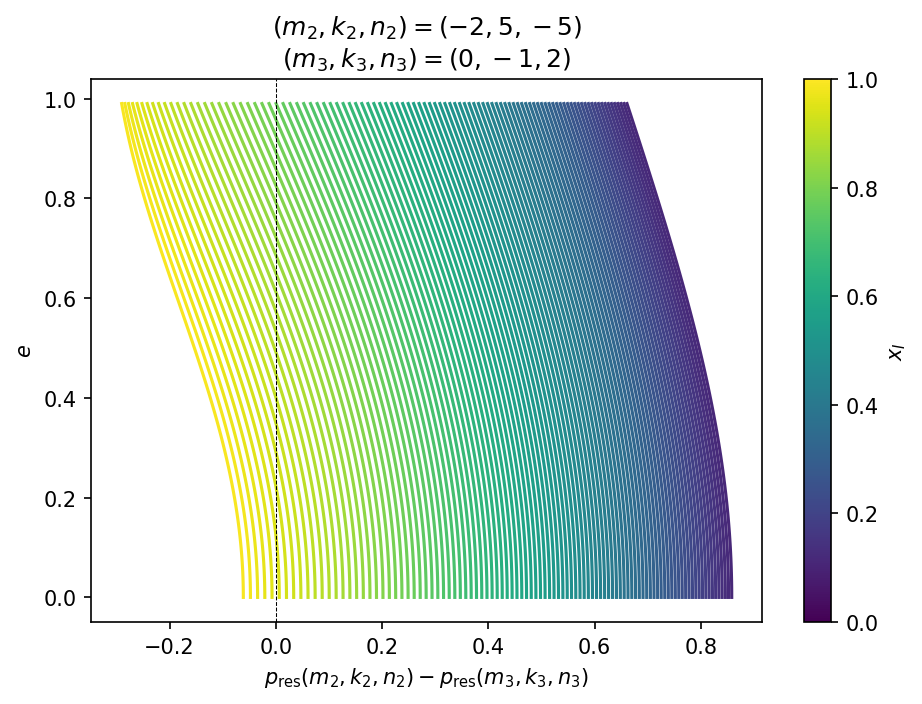

In [178]:
to_plot = p_res_1 - p_res_3
cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(dpi=150)
for k in range(len(xv)):
    ax.plot(to_plot[:,k], ev, c=cmap(xv[k]))
# plt.colorbar()
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax, label=r"$x_I$")
plt.axvline(0, color='black', linestyle='--', lw=0.5)
plt.xlabel(r"$p_\mathrm{res}(m_1, k_1, n_1) - p_\mathrm{res}(m_3, k_3, n_3)$")
plt.ylabel(r"$e$")
plt.title(fr"$(m_1, k_1, n_1) = ({m1:d}, {k1:d}, {n1:d})$" + "\n" + fr"$(m_3, k_3, n_3) = ({m3:d}, {k3:d}, {n3:d})$")
plt.tight_layout()
plt.show()

to_plot = p_res_2 - p_res_3
cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(dpi=150)
for k in range(len(xv)):
    ax.plot(to_plot[:,k], ev, c=cmap(xv[k]))
# plt.colorbar()
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax, label=r"$x_I$")
plt.axvline(0, color='black', linestyle='--', lw=0.5)
plt.xlabel(r"$p_\mathrm{res}(m_2, k_2, n_2) - p_\mathrm{res}(m_3, k_3, n_3)$")
plt.ylabel(r"$e$")
plt.title(fr"$(m_2, k_2, n_2) = ({m2:d}, {k2:d}, {n2:d})$" + "\n" + fr"$(m_3, k_3, n_3) = ({m3:d}, {k3:d}, {n3:d})$")
plt.tight_layout()
plt.show()
